In [1]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import networkx as nx
from sklearn import metrics
from matplotlib import gridspec


import seaborn as sns
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
from matplotlib import dates
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs_nei import *
from veiw import *

q = [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
dongs = ['강남동', '교  동', '근화동', '남  면', '남산면', '동  면', '동내면', '동산면', '북산면','사북면', '서  면', '석사동', '소양동', '신동면', '신북읍', '신사우동', '약사명동', '조운동','퇴계동', '효자1동', '후평1동']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [2]:
def dong_f2(training, tft ,data, dong , ewma_funs, factor , n : int , round_cut : float):
    prediction_df = pd.DataFrame()
    for file in sorted(os.listdir('./test_data'))[1:]:
        val_data = data_processing('./test_data/' + file , factor , ewma_funs)
        val_data = val_data.fillna(0)
        validation = TimeSeriesDataSet.from_dataset(training, val_data, predict=True, stop_randomization=True)
        val_dataloader = validation.to_dataloader(train=False, batch_size=16, num_workers=0)
        pred , x, idx_df = tft.predict(val_dataloader, mode='raw', return_x = True , return_index = True)
        idx = idx_df[idx_df['h_dong'] == dong].index[0]
        
        xyz = pd.DataFrame()
        delta_h = val_data['REG_DTIME'].unique()[1] - val_data['REG_DTIME'].unique()[0] 
        s = val_data['REG_DTIME'].unique().max() + delta_h
        e = val_data['REG_DTIME'].unique().max() + 24*delta_h

        #print(pd.date_range(s,e ,freq = 'h'))
        xyz.index = pd.date_range(s,e ,freq = 'h')
        xyz['prediction'] = pred['prediction'][idx, : , n]
        prediction_df = pd.concat([prediction_df, xyz])

    predition = prediction_df['prediction'][:-24]
    df_index = prediction_df.index[:-24]

    org_data = data_processing('nei_test.csv' , 0 , None)
    org_data = org_data[org_data['h_dong'] == dong]
    org_count = org_data[org_data['REG_DTIME'].isin(df_index)]['count']

    
    org_count = org_count.to_numpy()
    org_count = np.logical_not(org_count < 1)
    predition = predition
    predition = np.logical_not(predition < round_cut)
    return metrics.fbeta_score(org_count,predition , 2)

    
def get_f2(training, tft ,data, ewma_funs, factor):
    result_df = pd.DataFrame()
    for round_cut in [0.3 , 0.5 , 0.7 , 0.9]:
        f2_df = pd.DataFrame(columns = ['h_dong' , f'f2_score {round_cut}'])
        for idx, dong in enumerate(dongs):
            f2_df.loc[idx,'h_dong'] = dong
            f2_df.loc[idx,f'f2_score {round_cut}'] = dong_f2(training, tft ,data, dong ,ewma_funs, factor,3,round_cut )
        f2_df.loc[idx+1, 'h_dong'] = 'all'
        f2_df.loc[idx+1, f'f2_score {round_cut}'] = np.mean(f2_df[f'f2_score {round_cut}'])
        f2_df = f2_df.sort_values(by=f'f2_score {round_cut}' , ascending=False)
        result_df = pd.concat([result_df, f2_df],axis=1)
    return result_df

## result

In [5]:
model_ckpt = 'ckpt/lightning_logs/version_53/checkpoints/epoch=299-step=6000.ckpt'
factor = 0.1
funs = moving_average_alpha_both

train_data = data_processing('nei_train.csv' , factor , funs)
test_data = data_processing('nei_test.csv' , factor, funs)
training = get_training(train_data,'log' , 24, 24*7)
tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)

In [4]:
get_f2(training, tft ,test_data, funs, factor)

,h_dong,f2_score 0.3,h_dong,f2_score 0.5,h_dong,f2_score 0.7,h_dong,f2_score 0.9
15,신사우동,0.13245,신사우동,0.0,신사우동,0.0,신사우동,0.0
5,동 면,0.128205,동 면,0.0,동 면,0.0,동 면,0.0
19,효자1동,0.127551,효자1동,0.076923,효자1동,0.0,효자1동,0.0
18,퇴계동,0.103448,퇴계동,0.022422,퇴계동,0.0,퇴계동,0.0
11,석사동,0.09375,석사동,0.086957,석사동,0.0,석사동,0.0
14,신북읍,0.081301,신북읍,0.0,신북읍,0.0,신북읍,0.0
0,강남동,0.078947,강남동,0.0,강남동,0.0,강남동,0.0
4,남산면,0.076923,남산면,0.0,남산면,0.0,남산면,0.0
20,후평1동,0.042194,후평1동,0.028736,후평1동,0.0,후평1동,0.0
21,all,0.04118,all,0.01024,all,0.0,all,0.0


In [6]:
from veiw import * 

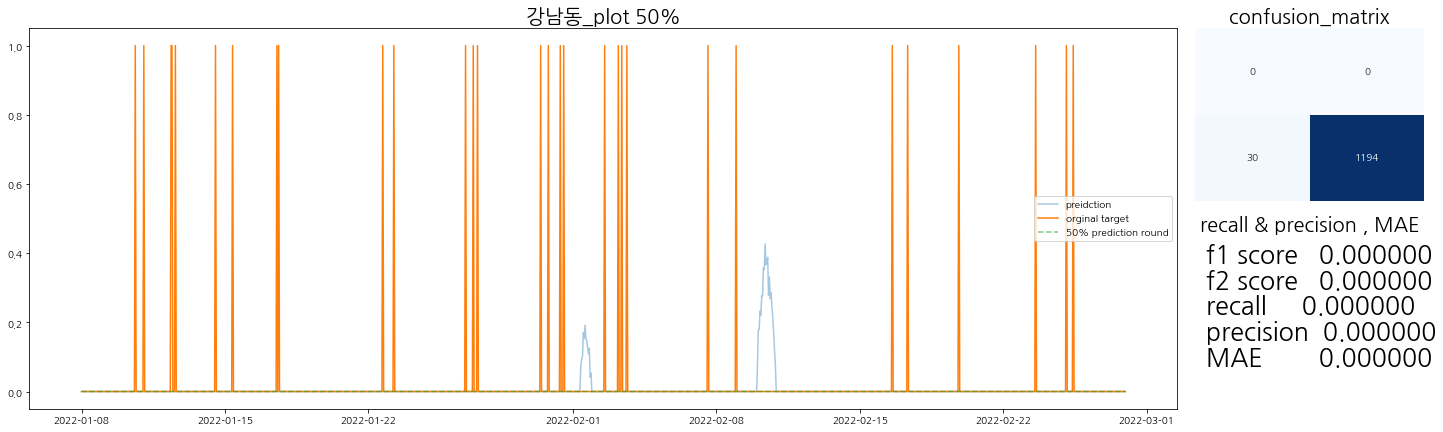

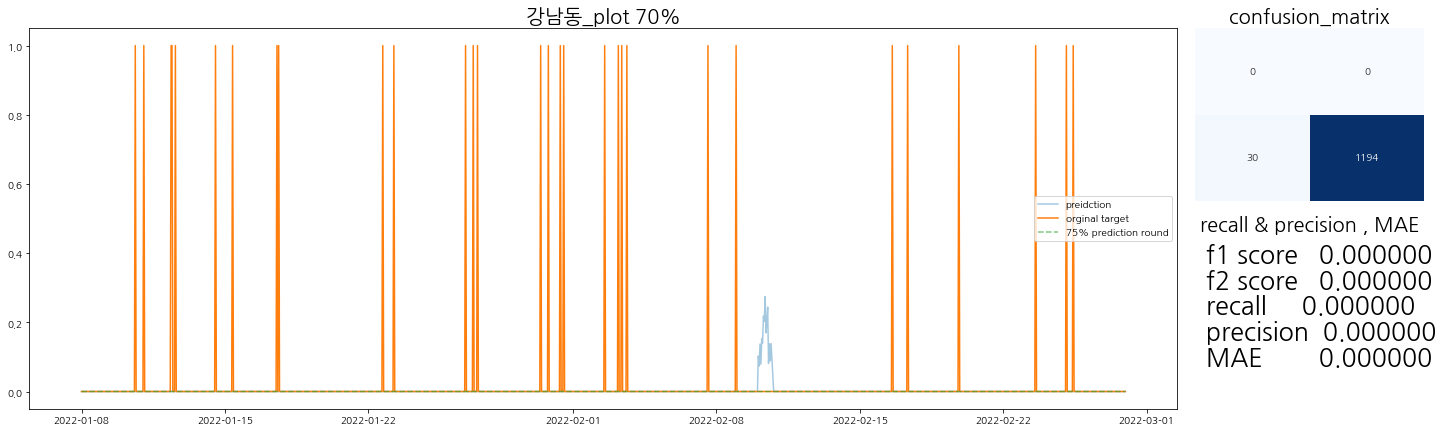

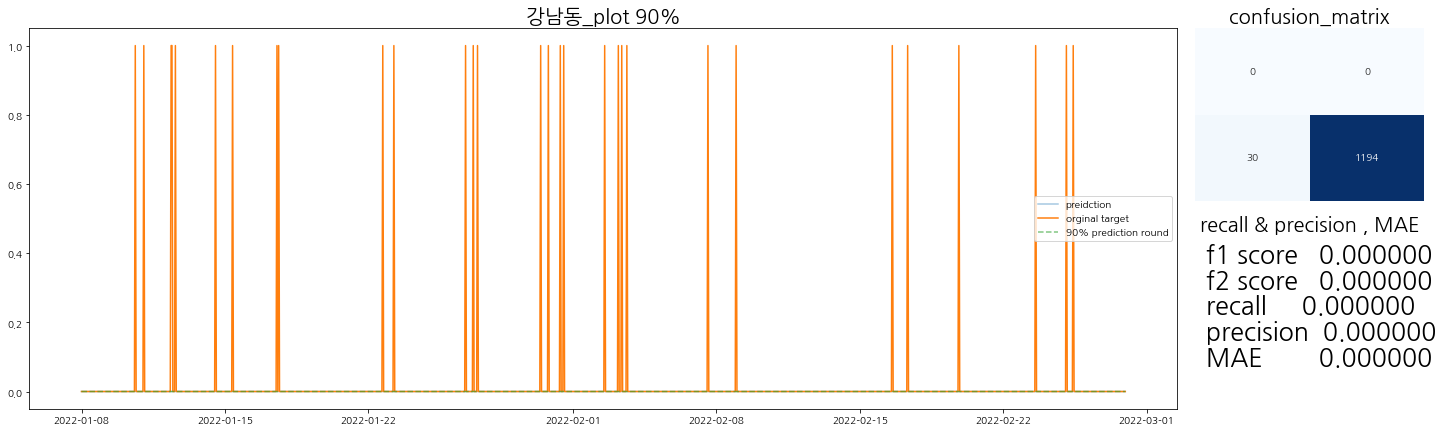

In [7]:
confusion_matrix_plot50(training, tft ,test_data ,'강남동' , '50%', funs, factor)
confusion_matrix_plot75(training, tft ,test_data ,'강남동' , '70%', funs, factor)
confusion_matrix_plot90(training, tft ,test_data ,'강남동' , '90%', funs, factor)

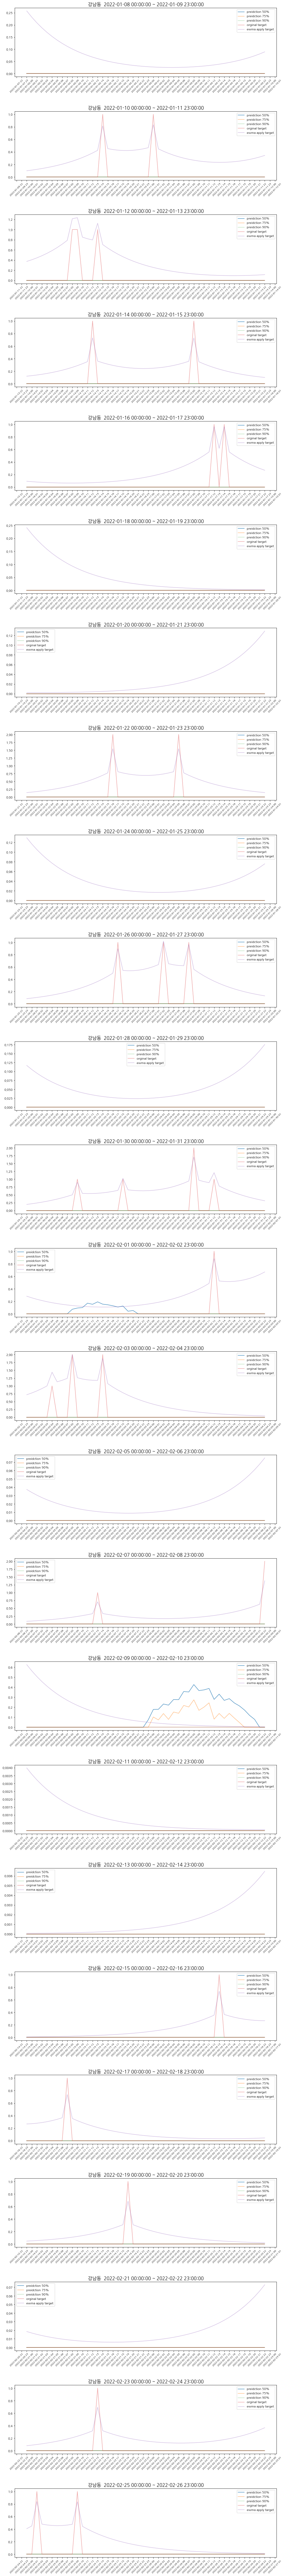

In [8]:
model_ckpt = 'ckpt/lightning_logs/version_53/checkpoints/epoch=299-step=6000.ckpt'
factor = 0.1
funs = moving_average_alpha_both

train_data = data_processing('nei_train.csv' , factor , funs)
test_data = data_processing('nei_test.csv' , factor, funs)
training = get_training(train_data,'log' , 24, 24*7)
tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)

prediction_plot_n(training, tft ,test_data, '강남동' , f'emwa : alpha , factor : {factor}' , funs, factor)